In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Loops

### Motivation

In [9]:
odds = [1, 3, 5, 7]

In [10]:
print("*"+str(odds[0])+"*")
print(odds[1])
print(odds[2])
print(odds[3])

*1*
3
5
7


There are at least three reasons to use another approach:
- Not scalable
- Difficult to maintain
- Fragile

### for loops

In [25]:
odds = [1, 3, 5, 7] * 5

In [26]:
for number in odds:
    print("*" + str(number) + "*")

*1*
*3*
*5*
*7*
*1*
*3*
*5*
*7*
*1*
*3*
*5*
*7*
*1*
*3*
*5*
*7*
*1*
*3*
*5*
*7*


In [27]:
odds = [1, 3, 5, 7]

In [32]:
for number in odds:
    print("Number: " + str(number))
    print("Double: " + str(number*2))
print("Done")

Number: 1
Double: 2
Number: 3
Double: 6
Number: 5
Double: 10
Number: 7
Double: 14
Done


In [34]:
odd = 9

In [35]:
for odd in odds:
    print(odd)

1
3
5
7


In [36]:
odd

7

In [37]:
number

7

In [40]:
counter = 0
for _ in odds:
    counter = counter + 1
print(counter)

4


In [41]:
len(odds)

4

### Exercise

Write a for loop that calculates the sum of a list of numbers

Try it on `numbers = [1,2,3,4,5,11]`

In [42]:
numbers = [1,2,3,4,5,11]

In [52]:
result = 0
for number in numbers:
    result = result + number
print(result)

26


In [51]:
sum(numbers)

26

## Getting file lists

In [68]:
import glob

In [75]:
files = sorted(glob.glob("data/inflammation*.csv"))

In [76]:
files

['data/inflammation-01.csv',
 'data/inflammation-02.csv',
 'data/inflammation-03.csv',
 'data/inflammation-04.csv',
 'data/inflammation-05.csv',
 'data/inflammation-06.csv',
 'data/inflammation-07.csv',
 'data/inflammation-08.csv',
 'data/inflammation-09.csv',
 'data/inflammation-10.csv',
 'data/inflammation-11.csv',
 'data/inflammation-12.csv']

In [91]:
[f.replace("/", "\\") for f in files]

['data\\inflammation-01.csv',
 'data\\inflammation-02.csv',
 'data\\inflammation-03.csv',
 'data\\inflammation-04.csv',
 'data\\inflammation-05.csv',
 'data\\inflammation-06.csv',
 'data\\inflammation-07.csv',
 'data\\inflammation-08.csv',
 'data\\inflammation-09.csv',
 'data\\inflammation-10.csv',
 'data\\inflammation-11.csv',
 'data\\inflammation-12.csv']

In [92]:
print("bla\nblub\tfoo\tbar")

bla
blub	foo	bar


### Task

Create a for loop, that creates the figure with three subplots from yesterday, for each of the inflammation csv files. 

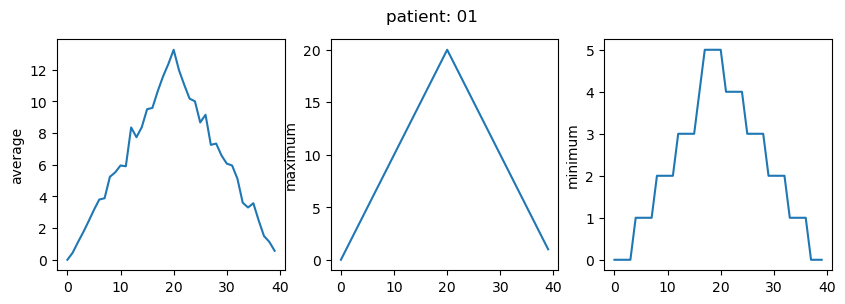

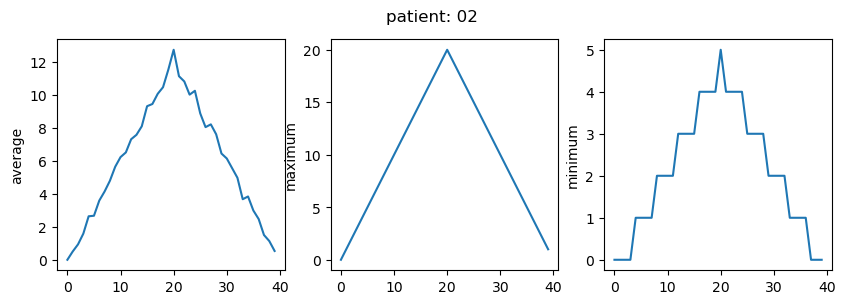

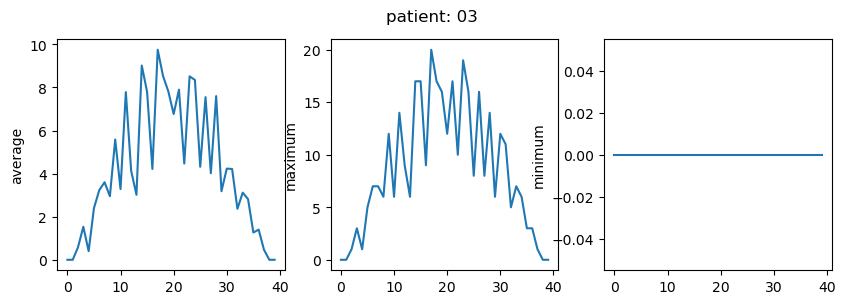

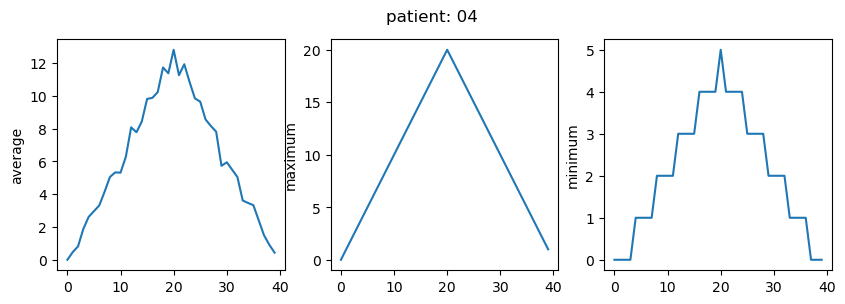

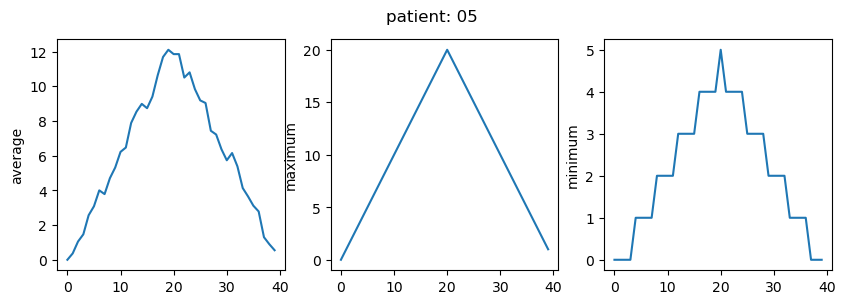

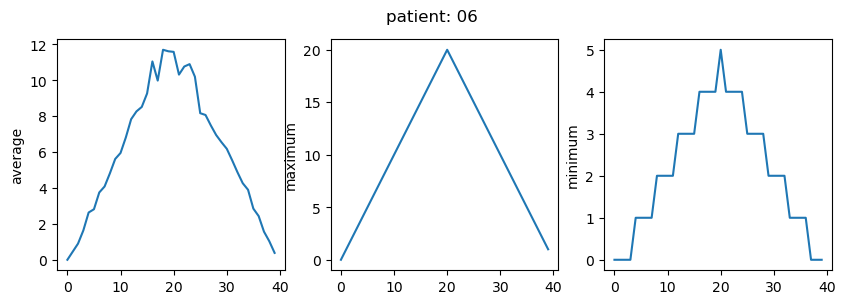

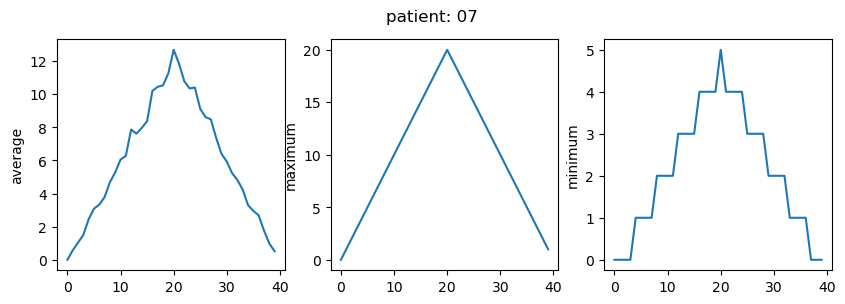

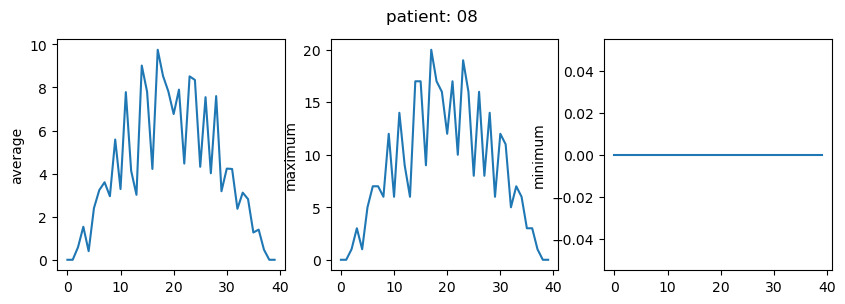

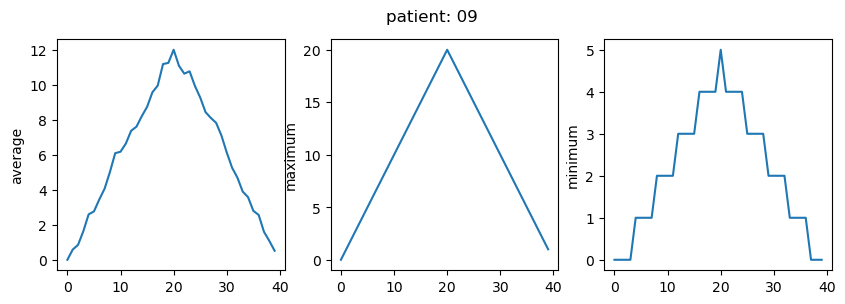

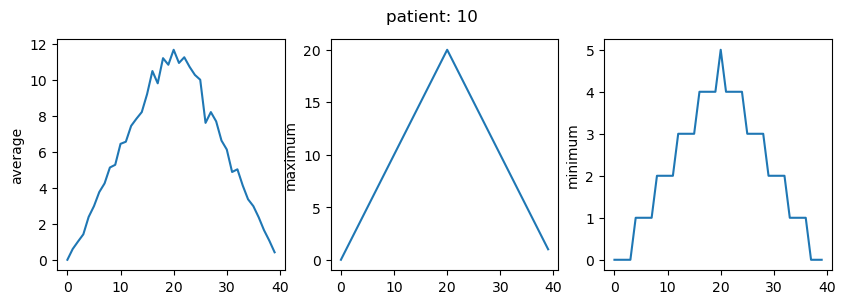

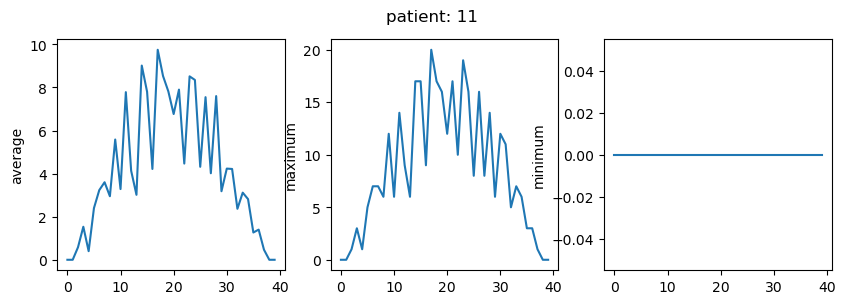

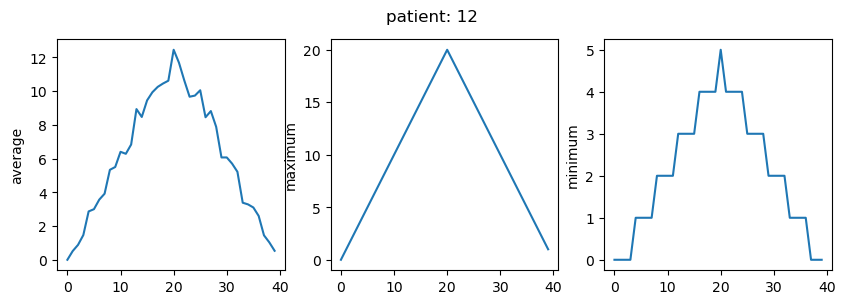

In [103]:
for file in files:
    data = np.loadtxt(file, delimiter=",")
    fig = plt.figure(figsize=(10,3))
    fig.suptitle(file.replace("data/inflammation-","patient: ").replace(".csv", ""))
    axes1 = fig.add_subplot(1, 3, 1)
    axes2 = fig.add_subplot(1, 3, 2)
    axes3 = fig.add_subplot(1, 3, 3)
    axes1.plot(np.mean(data, axis=0))
    axes1.set_ylabel("average")
    axes2.plot(np.max(data, axis=0))
    axes2.set_ylabel("maximum")
    axes3.plot(np.min(data, axis=0))
    axes3.set_ylabel("minimum")
    fig.savefig(file.replace(".csv",".png"))
    #plt.show()
    #plt.close()

## Making choices

In [121]:
temperature = 15
if temperature < 20:
    print("Cold")
    print("Cold")
    print("Cold")
elif temperature == 20:
    pass
elif temperature < 30:
    print("Hot")
else:
    print("Super hot")

Cold
Cold
Cold


### boolean type

In [122]:
True

True

In [124]:
type(False)

bool

In [125]:
3 > 5

False

In [126]:
5 > 3

True

In [127]:
a = 5
b = 7
print(a > b)
print(a >= b)
print(a < b)
print(a <= b)
print(a == b)
print(a != b)

False
False
True
True
False
True


In [131]:
"3" == 3

False

In [132]:
3 == 3.0

True

### Truthiness

In [139]:
if 0:
    print("yes")
else:
    print("no")

no


In [140]:
True or False

True

In [141]:
False or True

True

In [142]:
False or False

False

In [143]:
True or True

True

In [146]:
a = 12
if a < 3 or a > 10:
    print("a is special")

a is special


In [149]:
a = 5
if a >= 3 and a <= 10:
    print("a is not very special")

a is not very special


In [150]:
not True

False

In [151]:
not False

True

In [156]:
max_per_day = np.max(data, axis=0)
min_per_day = np.min(data, axis=0)
if max_per_day[10] == 10 and max_per_day[20] == 20:
    print("Something is weird with the max")
if sum(min_per_day) == 0:
    print("All minima per day sum to 0")

Something is weird with the max


In [155]:
max_per_day

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18., 19., 20., 19., 18., 17., 16., 15.,
       14., 13., 12., 11., 10.,  9.,  8.,  7.,  6.,  5.,  4.,  3.,  2.,
        1.])

In [166]:
errors = {}
for file in files:
    print(file)
    errors[file] = ""
    data = np.loadtxt(file, delimiter=",")
    max_per_day = np.max(data, axis=0)
    min_per_day = np.min(data, axis=0)
    if max_per_day[10] == 10 and max_per_day[20] == 20:
        print("Something is weird with the max")
        errors[file] += "max"
    if sum(min_per_day) == 0:
        print("All minima per day sum to 0")
        errors[file] += "min"

data/inflammation-01.csv
Something is weird with the max
data/inflammation-02.csv
Something is weird with the max
data/inflammation-03.csv
All minima per day sum to 0
data/inflammation-04.csv
Something is weird with the max
data/inflammation-05.csv
Something is weird with the max
data/inflammation-06.csv
Something is weird with the max
data/inflammation-07.csv
Something is weird with the max
data/inflammation-08.csv
All minima per day sum to 0
data/inflammation-09.csv
Something is weird with the max
data/inflammation-10.csv
Something is weird with the max
data/inflammation-11.csv
All minima per day sum to 0
data/inflammation-12.csv
Something is weird with the max


In [167]:
errors

{'data/inflammation-01.csv': 'max',
 'data/inflammation-02.csv': 'max',
 'data/inflammation-03.csv': 'min',
 'data/inflammation-04.csv': 'max',
 'data/inflammation-05.csv': 'max',
 'data/inflammation-06.csv': 'max',
 'data/inflammation-07.csv': 'max',
 'data/inflammation-08.csv': 'min',
 'data/inflammation-09.csv': 'max',
 'data/inflammation-10.csv': 'max',
 'data/inflammation-11.csv': 'min',
 'data/inflammation-12.csv': 'max'}

In [159]:
ages = {"Person A": 23, "Person B": 21}

In [160]:
ages["Person B"]

21

In [161]:
ages["Person F"] = 39

In [162]:
ages

{'Person A': 23, 'Person B': 21, 'Person F': 39}

In [165]:
a = 0
a = a + 2
a += 2
print(a)

4


## Functions

In [170]:
def print_hi():
    print("Hi there!")

In [173]:
print_hi()

Hi there!


In [175]:
def add_one(number):
    return number + 1

In [176]:
add_one(17) - 3

15

In [178]:
print(add_one(17))
2 + 2

18


4

In [181]:
def check_file(file):
    print(file)
    data = np.loadtxt(file, delimiter=",")
    check_max(data)
    check_min(data)

In [183]:
def check_max(data):
    max_per_day = np.max(data, axis = 0)
    if max_per_day[10] == 10 and max_per_day[20] == 20:
        print("Something is weird with the max")

In [184]:
def check_min(data):
    min_per_day = np.min(data, axis=0)
    if sum(min_per_day) == 0:
        print("All minima per day sum to 0")

In [185]:
for file in files:
    check_file(file)

data/inflammation-01.csv
Something is weird with the max
data/inflammation-02.csv
Something is weird with the max
data/inflammation-03.csv
All minima per day sum to 0
data/inflammation-04.csv
Something is weird with the max
data/inflammation-05.csv
Something is weird with the max
data/inflammation-06.csv
Something is weird with the max
data/inflammation-07.csv
Something is weird with the max
data/inflammation-08.csv
All minima per day sum to 0
data/inflammation-09.csv
Something is weird with the max
data/inflammation-10.csv
Something is weird with the max
data/inflammation-11.csv
All minima per day sum to 0
data/inflammation-12.csv
Something is weird with the max


## We continue at 2:20 pm